### 04.2 - Árvores e Ensembles

**Objetivo**  
- **Decision Tree**
- **Random Forest**
- **HistGradientBoosting**
- **AdaBoost**
- **XGBoost**

A proposta é combinar interpretação conceitual, métricas corretas e diagnóstico visual.

**Roadmap**
1. Conceito do zero e API comum
2. Fórmulas essenciais em LaTeX
3. Cenários sintéticos controlados
4. Métodos na prática (classificação e regressão)
5. Comparativo final com validação cruzada
6. Erros comuns e checklist

In [60]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

In [61]:
from sklearn.datasets import (
    make_circles,
    make_classification,
    make_friedman1,
    make_moons,
    make_regression,
)
from sklearn.dummy import DummyClassifier, DummyRegressor


In [62]:
from sklearn.ensemble import (
    AdaBoostClassifier,
    AdaBoostRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)


In [63]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PredictionErrorDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    root_mean_squared_error,
)


In [64]:
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    ValidationCurveDisplay,
    cross_validate,
    train_test_split,
)


In [65]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor
import xgboost as xgb

In [66]:
np.random.seed(42)
sns.set_theme(style='whitegrid', context='notebook')

### 1 - Conceito do zero

Árvores de decisão aprendem regras do tipo **se-então** com partições sucessivas do espaço de features.  
Ensembles combinam múltiplas árvores para aumentar robustez e reduzir erro.

- **Bagging** (Random Forest): reduz variância combinando árvores treinadas em amostras diferentes.
- **Boosting** (AdaBoost, GBM, XGBoost): reduz viés treinando modelos em sequência, focando erros anteriores.

**API comum**
- **fit(X, y)**
- **predict(X)**
- **predict_proba(X)**
- **score(X, y)**

Isso permite comparar métodos mudando pouco código.

In [67]:
X_demo, y_demo = make_classification(
    n_samples=120,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    random_state=42,
)

demo_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
demo_tree.fit(X_demo, y_demo)
print('Predições de exemplo:', demo_tree.predict(X_demo[:5]))

Predições de exemplo: [1 1 1 0 0]


### 3 - Cenários sintéticos

Vamos criar cenários simples e difíceis para avaliar comportamento dos métodos. A ideia é não depender de um único tipo de dado.

### 3.1 - Classificação linear 2D

Cenário para visualizar fronteira de decisão com clareza.

In [68]:
X_class_linear_2d, y_class_linear_2d = make_classification(
    n_samples=900,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.7,
    flip_y=0.02,
    random_state=42,
)
X_class_linear_2d = pd.DataFrame(X_class_linear_2d, columns=['x1', 'x2'])
y_class_linear_2d = pd.Series(y_class_linear_2d, name='target')

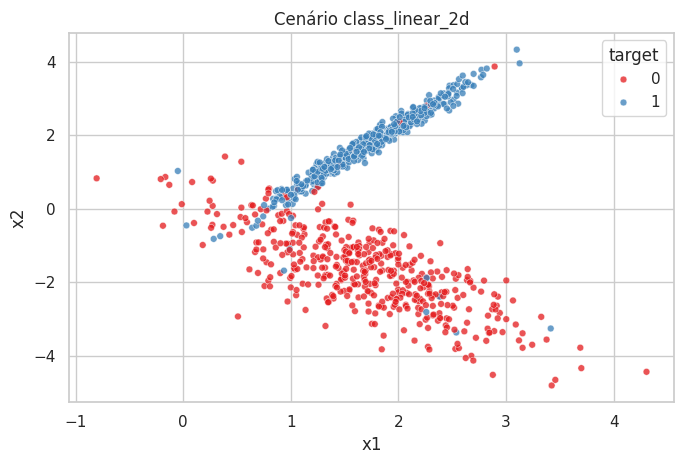

In [69]:
plt.figure(figsize=(7, 4.8))
sns.scatterplot(
    data=X_class_linear_2d.assign(target=y_class_linear_2d),
    x='x1',
    y='x2',
    hue='target',
    palette='Set1',
    s=24,
    alpha=0.75,
)
plt.title('Cenário class_linear_2d')
plt.tight_layout()

### 3.2 - Classificação não linear

Aqui o objetivo é testar métodos de árvore em fronteiras curvas.

In [70]:
X_moons, y_moons = make_moons(n_samples=900, noise=0.22, random_state=42)
X_circles, y_circles = make_circles(n_samples=900, noise=0.12, factor=0.45, random_state=42)

X_class_nonlinear = pd.DataFrame(X_moons, columns=['x1', 'x2'])
y_class_nonlinear = pd.Series(y_moons, name='target')

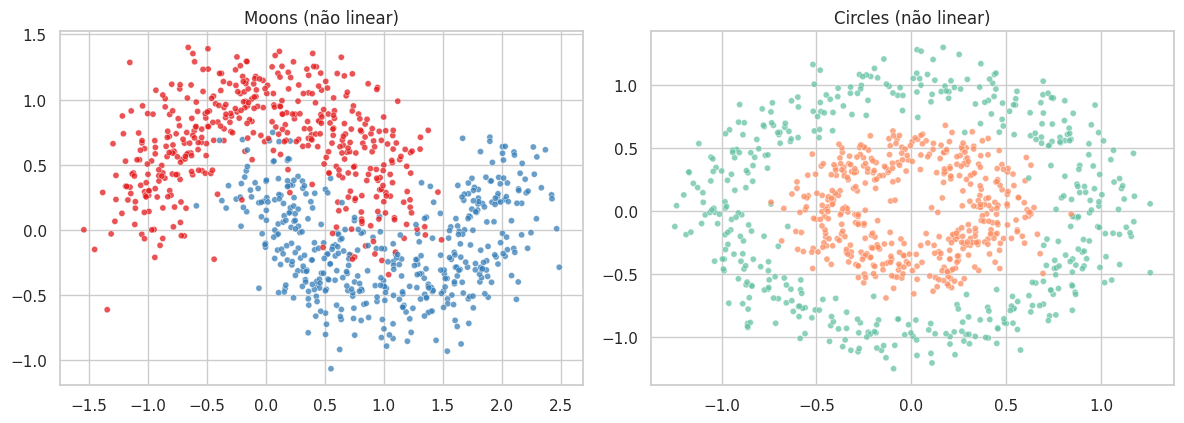

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

sns.scatterplot(
    x=X_moons[:, 0], y=X_moons[:, 1], hue=y_moons,
    palette='Set1', s=20, alpha=0.75, ax=axes[0], legend=False,
)
axes[0].set_title('Moons (não linear)')

sns.scatterplot(
    x=X_circles[:, 0], y=X_circles[:, 1], hue=y_circles,
    palette='Set2', s=20, alpha=0.75, ax=axes[1], legend=False,
)
axes[1].set_title('Circles (não linear)')

plt.tight_layout()

### 3.3 - Classificação desbalanceada

Vamos usar esse cenário para avaliar métricas além de accuracy.

In [72]:
X_class_imbalanced, y_class_imbalanced = make_classification(
    n_samples=5200,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    weights=[0.9, 0.1],
    flip_y=0.03,
    class_sep=1.0,
    random_state=42,
)
X_class_imbalanced = pd.DataFrame(X_class_imbalanced, columns=[f'x{i}' for i in range(1, 21)])
y_class_imbalanced = pd.Series(y_class_imbalanced, name='target')

In [73]:
balance_df = y_class_imbalanced.value_counts(normalize=True).rename('proporcao').reset_index()
balance_df.columns = ['classe', 'proporcao']
balance_df

,classe,proporcao
0,0,0.887308
1,1,0.112692


### 3.4 - Classificação de alto volume

Cenário usado para comparar HistGradientBoosting e XGBoost.

In [74]:
X_class_high_volume, y_class_high_volume = make_classification(
    n_samples=12000,
    n_features=25,
    n_informative=12,
    n_redundant=8,
    weights=[0.6, 0.4],
    class_sep=1.1,
    flip_y=0.02,
    random_state=52,
)
X_class_high_volume = pd.DataFrame(X_class_high_volume, columns=[f'x{i}' for i in range(1, 26)])
y_class_high_volume = pd.Series(y_class_high_volume, name='target')

### 3.5 - Regressão piecewise

Neste cenário, o alvo muda por faixas, favorecendo modelos baseados em partições.

In [75]:
rng = np.random.default_rng(42)
x_piece = rng.uniform(-4, 4, 1800)
y_piece = np.where(
    x_piece < -1,
    1.8 * x_piece + 6,
    np.where(x_piece < 1.5, -1.2 * x_piece + 1.2, 0.9 * x_piece - 2.5),
)
y_piece = y_piece + rng.normal(0, 0.75, size=x_piece.shape[0])

X_reg_piecewise = pd.DataFrame({'x1': x_piece})
y_reg_piecewise = pd.Series(y_piece, name='target')

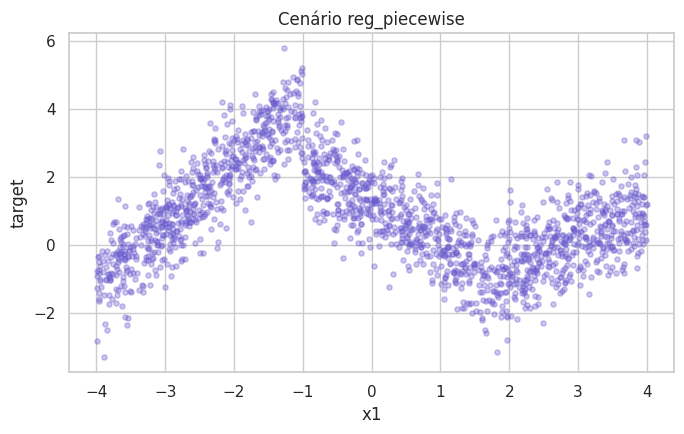

In [76]:
plt.figure(figsize=(7, 4.5))
plt.scatter(X_reg_piecewise['x1'], y_reg_piecewise, s=14, alpha=0.35, color='slateblue')
plt.title('Cenário reg_piecewise')
plt.xlabel('x1')
plt.ylabel('target')
plt.tight_layout()

### 3.6 - Regressão Friedman

Cenário clássico não linear com interações entre variáveis.

In [77]:
X_reg_friedman, y_reg_friedman = make_friedman1(
    n_samples=4200,
    n_features=10,
    noise=1.2,
    random_state=42,
)
X_reg_friedman = pd.DataFrame(X_reg_friedman, columns=[f'x{i}' for i in range(1, 11)])
y_reg_friedman = pd.Series(y_reg_friedman, name='target')

### 3.7 - Regressão de alto volume

Usaremos este cenário para benchmark de tempo/performance em ensembles.

In [78]:
X_reg_high_volume, y_reg_high_volume = make_regression(
    n_samples=100_000,
    n_features=20,
    n_informative=12,
    noise=26.0,
    random_state=59,
)
X_reg_high_volume = pd.DataFrame(X_reg_high_volume, columns=[f'x{i}' for i in range(1, 21)])
y_reg_high_volume = pd.Series(y_reg_high_volume, name='target')

In [79]:
scenario_summary = pd.DataFrame([
    ['classificacao', 'class_linear_2d', X_class_linear_2d.shape[0], X_class_linear_2d.shape[1]],
    ['classificacao', 'class_nonlinear', X_class_nonlinear.shape[0], X_class_nonlinear.shape[1]],
    ['classificacao', 'class_imbalanced', X_class_imbalanced.shape[0], X_class_imbalanced.shape[1]],
    ['classificacao', 'class_high_volume', X_class_high_volume.shape[0], X_class_high_volume.shape[1]],
    ['regressao', 'reg_piecewise', X_reg_piecewise.shape[0], X_reg_piecewise.shape[1]],
    ['regressao', 'reg_friedman', X_reg_friedman.shape[0], X_reg_friedman.shape[1]],
    ['regressao', 'reg_high_volume', X_reg_high_volume.shape[0], X_reg_high_volume.shape[1]],
], columns=['tipo', 'cenario', 'amostras', 'features'])
scenario_summary

,tipo,cenario,amostras,features
0,classificacao,class_linear_2d,900,2
1,classificacao,class_nonlinear,900,2
2,classificacao,class_imbalanced,5200,20
3,classificacao,class_high_volume,12000,25
4,regressao,reg_piecewise,1800,1
5,regressao,reg_friedman,4200,10
6,regressao,reg_high_volume,100000,20


### 4 - Método 1: Decision Tree (Classifier + Regressor)

Árvores únicas são muito interpretáveis, mas podem superajustar facilmente.  
Vamos comparar versão padrão e versão regularizada.

In [80]:
X_train_tree_cls, X_test_tree_cls, y_train_tree_cls, y_test_tree_cls = train_test_split(
    X_class_nonlinear,
    y_class_nonlinear,
    test_size=0.25,
    random_state=42,
    stratify=y_class_nonlinear,
)

tree_cls_default = DecisionTreeClassifier(random_state=42)
tree_cls_reg = DecisionTreeClassifier(max_depth=5, min_samples_leaf=8, random_state=42)

tree_cls_default.fit(X_train_tree_cls, y_train_tree_cls)
tree_cls_reg.fit(X_train_tree_cls, y_train_tree_cls)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [81]:
rows_tree_cls = []
for name, model in [('Tree_default', tree_cls_default), ('Tree_regularizada', tree_cls_reg)]:
    pred = model.predict(X_test_tree_cls)
    score = model.predict_proba(X_test_tree_cls)[:, 1]
    rows_tree_cls.append({
        'model': name,
        'accuracy_test': accuracy_score(y_test_tree_cls, pred),
        'balanced_accuracy_test': balanced_accuracy_score(y_test_tree_cls, pred),
        'precision_test': precision_score(y_test_tree_cls, pred, zero_division=0),
        'recall_test': recall_score(y_test_tree_cls, pred, zero_division=0),
        'f1_test': f1_score(y_test_tree_cls, pred, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_tree_cls, score),
    })

tree_cls_table = pd.DataFrame(rows_tree_cls).sort_values('f1_test', ascending=False).reset_index(drop=True)
tree_cls_table.round(4)

,model,accuracy_test,balanced_accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,Tree_regularizada,0.9644,0.9644,0.9727,0.9554,0.9640,0.9817
1,Tree_default,0.9333,0.9332,0.9709,0.8929,0.9302,0.9332


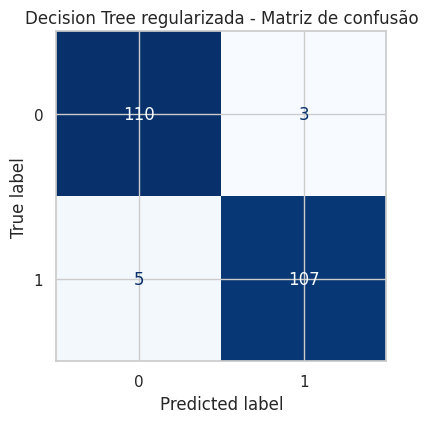

In [82]:
fig, ax = plt.subplots(figsize=(5, 4.4))
ConfusionMatrixDisplay.from_estimator(tree_cls_reg, X_test_tree_cls, y_test_tree_cls, cmap='Blues', colorbar=False, ax=ax)
ax.set_title('Decision Tree regularizada - Matriz de confusão')
plt.tight_layout()

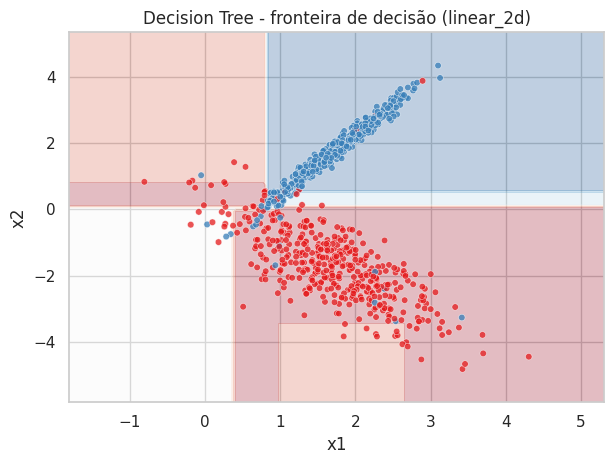

In [83]:
X_train_lin2d, X_test_lin2d, y_train_lin2d, y_test_lin2d = train_test_split(
    X_class_linear_2d,
    y_class_linear_2d,
    test_size=0.25,
    random_state=42,
    stratify=y_class_linear_2d,
)

tree_lin2d = DecisionTreeClassifier(max_depth=4, min_samples_leaf=6, random_state=42)
tree_lin2d.fit(X_train_lin2d, y_train_lin2d)

fig, ax = plt.subplots(figsize=(6.3, 4.8))
DecisionBoundaryDisplay.from_estimator(tree_lin2d, X_class_linear_2d, response_method='predict_proba', alpha=0.28, cmap='RdBu', ax=ax)
sns.scatterplot(data=X_class_linear_2d.assign(target=y_class_linear_2d), x='x1', y='x2', hue='target', palette='Set1', s=22, alpha=0.75, ax=ax, legend=False)
ax.set_title('Decision Tree - fronteira de decisão (linear_2d)')
plt.tight_layout()

In [84]:
X_train_tree_reg, X_test_tree_reg, y_train_tree_reg, y_test_tree_reg = train_test_split(
    X_reg_piecewise,
    y_reg_piecewise,
    test_size=0.25,
    random_state=42,
)

tree_reg_default = DecisionTreeRegressor(random_state=42)
tree_reg_reg = DecisionTreeRegressor(max_depth=5, min_samples_leaf=12, random_state=42)

tree_reg_default.fit(X_train_tree_reg, y_train_tree_reg)
tree_reg_reg.fit(X_train_tree_reg, y_train_tree_reg)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",12
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [85]:
rows_tree_reg = []
for name, model in [('TreeReg_default', tree_reg_default), ('TreeReg_regularizada', tree_reg_reg)]:
    pred_train = model.predict(X_train_tree_reg)
    pred_test = model.predict(X_test_tree_reg)
    rows_tree_reg.append({
        'model': name,
        'rmse_train': root_mean_squared_error(y_train_tree_reg, pred_train),
        'rmse_test': root_mean_squared_error(y_test_tree_reg, pred_test),
        'mae_test': mean_absolute_error(y_test_tree_reg, pred_test),
        'r2_test': r2_score(y_test_tree_reg, pred_test),
    })

tree_reg_table = pd.DataFrame(rows_tree_reg).sort_values('rmse_test').reset_index(drop=True)
tree_reg_table.round(4)

,model,rmse_train,rmse_test,mae_test,r2_test
0,TreeReg_regularizada,0.7497,0.8322,0.6674,0.6833
1,TreeReg_default,0.0000,1.0836,0.8706,0.4632


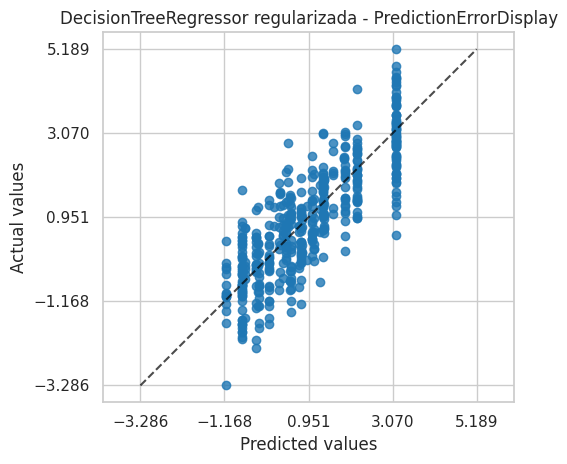

In [86]:
fig, ax = plt.subplots(figsize=(5.4, 4.8))
PredictionErrorDisplay.from_estimator(tree_reg_reg, X_test_tree_reg, y_test_tree_reg, kind='actual_vs_predicted', ax=ax)
ax.set_title('DecisionTreeRegressor regularizada - PredictionErrorDisplay')
plt.tight_layout()

In [87]:
depths = list(range(1, 15))
cls_depth_rows = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train_tree_cls, y_train_tree_cls)
    pred_train = m.predict(X_train_tree_cls)
    pred_test = m.predict(X_test_tree_cls)
    cls_depth_rows.append({
        'depth': d,
        'f1_train': f1_score(y_train_tree_cls, pred_train),
        'f1_test': f1_score(y_test_tree_cls, pred_test),
    })

cls_depth_df = pd.DataFrame(cls_depth_rows)

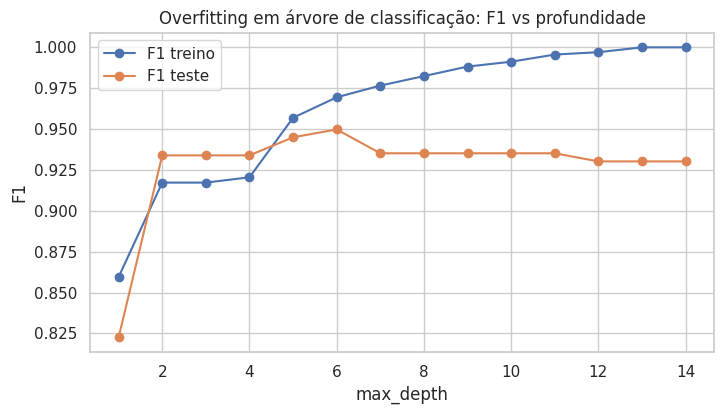

In [88]:
plt.figure(figsize=(7.4, 4.3))
plt.plot(cls_depth_df['depth'], cls_depth_df['f1_train'], marker='o', label='F1 treino')
plt.plot(cls_depth_df['depth'], cls_depth_df['f1_test'], marker='o', label='F1 teste')
plt.title('Overfitting em árvore de classificação: F1 vs profundidade')
plt.xlabel('max_depth')
plt.ylabel('F1')
plt.legend()
plt.tight_layout()

In [89]:
reg_depth_rows = []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train_tree_reg, y_train_tree_reg)
    pred_train = m.predict(X_train_tree_reg)
    pred_test = m.predict(X_test_tree_reg)
    reg_depth_rows.append({
        'depth': d,
        'rmse_train': root_mean_squared_error(y_train_tree_reg, pred_train),
        'rmse_test': root_mean_squared_error(y_test_tree_reg, pred_test),
    })

reg_depth_df = pd.DataFrame(reg_depth_rows)

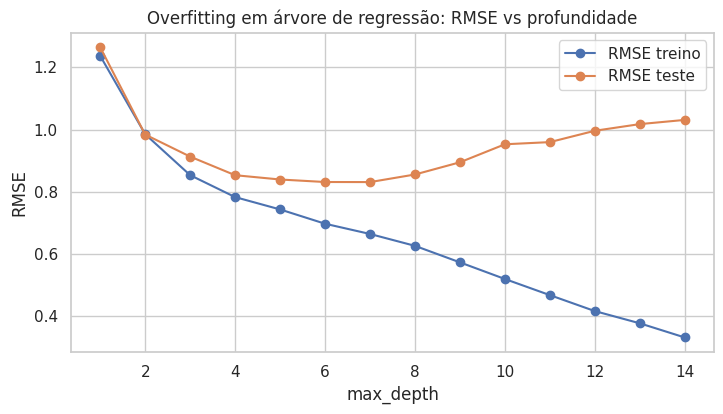

In [90]:
plt.figure(figsize=(7.4, 4.3))
plt.plot(reg_depth_df['depth'], reg_depth_df['rmse_train'], marker='o', label='RMSE treino')
plt.plot(reg_depth_df['depth'], reg_depth_df['rmse_test'], marker='o', label='RMSE teste')
plt.title('Overfitting em árvore de regressão: RMSE vs profundidade')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()

### 5 - Método 2: Random Forest (Classificador + Regressor)

A Random Forest combina várias árvores para reduzir variância e aumentar robustez. Vamos comparar com árvore única nos mesmos cenários.

In [91]:
rf_cls = RandomForestClassifier(
    n_estimators=160,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
)
rf_cls.fit(X_train_tree_cls, y_train_tree_cls)

rf_reg = RandomForestRegressor(
    n_estimators=180,
    max_depth=12,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
)
rf_reg.fit(X_train_tree_reg, y_train_tree_reg)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",180
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [92]:
rf_cls_pred = rf_cls.predict(X_test_tree_cls)
rf_cls_score = rf_cls.predict_proba(X_test_tree_cls)[:, 1]

rf_vs_tree_cls = pd.DataFrame([
    {
        'model': 'DecisionTree_regularizada',
        'accuracy_test': accuracy_score(y_test_tree_cls, tree_cls_reg.predict(X_test_tree_cls)),
        'balanced_accuracy_test': balanced_accuracy_score(y_test_tree_cls, tree_cls_reg.predict(X_test_tree_cls)),
        'f1_test': f1_score(y_test_tree_cls, tree_cls_reg.predict(X_test_tree_cls)),
        'roc_auc_test': roc_auc_score(y_test_tree_cls, tree_cls_reg.predict_proba(X_test_tree_cls)[:, 1]),
    },
    {
        'model': 'RandomForest',
        'accuracy_test': accuracy_score(y_test_tree_cls, rf_cls_pred),
        'balanced_accuracy_test': balanced_accuracy_score(y_test_tree_cls, rf_cls_pred),
        'f1_test': f1_score(y_test_tree_cls, rf_cls_pred),
        'roc_auc_test': roc_auc_score(y_test_tree_cls, rf_cls_score),
    },
]).sort_values('f1_test', ascending=False).reset_index(drop=True)

rf_vs_tree_cls.round(4)

,model,accuracy_test,balanced_accuracy_test,f1_test,roc_auc_test
0,DecisionTree_regularizada,0.9644,0.9644,0.9640,0.9817
1,RandomForest,0.9556,0.9555,0.9545,0.9886


In [93]:
rf_vs_tree_reg = pd.DataFrame([
    {
        'model': 'DecisionTreeReg_regularizada',
        'rmse_test': root_mean_squared_error(y_test_tree_reg, tree_reg_reg.predict(X_test_tree_reg)),
        'mae_test': mean_absolute_error(y_test_tree_reg, tree_reg_reg.predict(X_test_tree_reg)),
        'r2_test': r2_score(y_test_tree_reg, tree_reg_reg.predict(X_test_tree_reg)),
    },
    {
        'model': 'RandomForestRegressor',
        'rmse_test': root_mean_squared_error(y_test_tree_reg, rf_reg.predict(X_test_tree_reg)),
        'mae_test': mean_absolute_error(y_test_tree_reg, rf_reg.predict(X_test_tree_reg)),
        'r2_test': r2_score(y_test_tree_reg, rf_reg.predict(X_test_tree_reg)),
    },
]).sort_values('rmse_test').reset_index(drop=True)

rf_vs_tree_reg.round(4)

,model,rmse_test,mae_test,r2_test
0,RandomForestRegressor,0.8283,0.6665,0.6863
1,DecisionTreeReg_regularizada,0.8322,0.6674,0.6833


In [94]:
X_train_hv_cls, X_test_hv_cls, y_train_hv_cls, y_test_hv_cls = train_test_split(
    X_class_high_volume,
    y_class_high_volume,
    test_size=0.25,
    random_state=42,
    stratify=y_class_high_volume,
)

rf_cls_hv = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf_cls_hv.fit(X_train_hv_cls, y_train_hv_cls)

importances = pd.Series(rf_cls_hv.feature_importances_, index=X_class_high_volume.columns).sort_values(ascending=False).head(12)

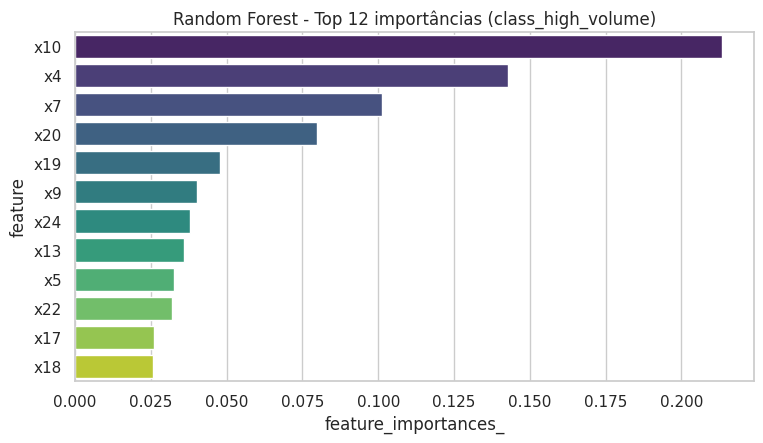

In [95]:
plt.figure(figsize=(7.8, 4.6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Random Forest - Top 12 importâncias (class_high_volume)')
plt.xlabel('feature_importances_')
plt.ylabel('feature')
plt.tight_layout()

Nota prática: **feature_importances** em árvores pode favorecer variáveis contínuas e features com mais possibilidades de corte. Interprete como sinal exploratório, não como verdade causal.

In [96]:
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_class_imbalanced,
    y_class_imbalanced,
    test_size=0.25,
    random_state=42,
    stratify=y_class_imbalanced,
)

tree_imb = DecisionTreeClassifier(max_depth=6, min_samples_leaf=8, random_state=42)
rf_imb = RandomForestClassifier(n_estimators=160, max_depth=10, min_samples_leaf=4, random_state=42, n_jobs=-1)

tree_imb.fit(X_train_imb, y_train_imb)
rf_imb.fit(X_train_imb, y_train_imb)

imb_table = pd.DataFrame([
    {
        'model': 'DecisionTree',
        'balanced_accuracy_test': balanced_accuracy_score(y_test_imb, tree_imb.predict(X_test_imb)),
        'f1_test': f1_score(y_test_imb, tree_imb.predict(X_test_imb), zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_imb, tree_imb.predict_proba(X_test_imb)[:, 1]),
    },
    {
        'model': 'RandomForest',
        'balanced_accuracy_test': balanced_accuracy_score(y_test_imb, rf_imb.predict(X_test_imb)),
        'f1_test': f1_score(y_test_imb, rf_imb.predict(X_test_imb), zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_imb, rf_imb.predict_proba(X_test_imb)[:, 1]),
    },
]).sort_values('f1_test', ascending=False).reset_index(drop=True)

imb_table.round(4)

,model,balanced_accuracy_test,f1_test,roc_auc_test
0,RandomForest,0.7800,0.7130,0.9316
1,DecisionTree,0.7571,0.6172,0.8383


In [97]:
X_train_fried, X_test_fried, y_train_fried, y_test_fried = train_test_split(
    X_reg_friedman,
    y_reg_friedman,
    test_size=0.25,
    random_state=42,
)

tree_fried = DecisionTreeRegressor(max_depth=7, min_samples_leaf=8, random_state=42)
rf_fried = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=4, random_state=42, n_jobs=-1)

tree_fried.fit(X_train_fried, y_train_fried)
rf_fried.fit(X_train_fried, y_train_fried)

fried_table = pd.DataFrame([
    {
        'model': 'DecisionTreeRegressor',
        'rmse_test': root_mean_squared_error(y_test_fried, tree_fried.predict(X_test_fried)),
        'mae_test': mean_absolute_error(y_test_fried, tree_fried.predict(X_test_fried)),
        'r2_test': r2_score(y_test_fried, tree_fried.predict(X_test_fried)),
    },
    {
        'model': 'RandomForestRegressor',
        'rmse_test': root_mean_squared_error(y_test_fried, rf_fried.predict(X_test_fried)),
        'mae_test': mean_absolute_error(y_test_fried, rf_fried.predict(X_test_fried)),
        'r2_test': r2_score(y_test_fried, rf_fried.predict(X_test_fried)),
    },
]).sort_values('rmse_test').reset_index(drop=True)

fried_table.round(4)

,model,rmse_test,mae_test,r2_test
0,RandomForestRegressor,1.7605,1.3777,0.8768
1,DecisionTreeRegressor,2.4998,1.9882,0.7517


### 6 - Método 3: Gradient Boosting (HistGB + XGBoost)

Agora vamos comparar boosting moderno do sklearn com XGBoost em cenários de maior volume.

In [98]:
X_train_hv_reg, X_test_hv_reg, y_train_hv_reg, y_test_hv_reg = train_test_split(
    X_reg_high_volume,
    y_reg_high_volume,
    test_size=0.25,
    random_state=42,
)

hgb_cls = HistGradientBoostingClassifier(
    learning_rate=0.06,
    max_leaf_nodes=31,
    max_iter=260,
    random_state=42,
)

xgb_cls = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    learning_rate=0.06,
    max_depth=6,
    n_estimators=240,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
)

hgb_reg = HistGradientBoostingRegressor(
    learning_rate=0.06,
    max_leaf_nodes=31,
    max_iter=260,
    random_state=42,
)

xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    learning_rate=0.06,
    max_depth=6,
    n_estimators=240,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
)

In [99]:
rows_gb_cls = []
for name, model in [('HistGBClassifier', hgb_cls), ('XGBClassifier', xgb_cls)]:
    t0 = time.perf_counter()
    model.fit(X_train_hv_cls, y_train_hv_cls)
    fit_time = time.perf_counter() - t0
    pred = model.predict(X_test_hv_cls)
    score = model.predict_proba(X_test_hv_cls)[:, 1]
    rows_gb_cls.append({
        'model': name,
        'balanced_accuracy_test': balanced_accuracy_score(y_test_hv_cls, pred),
        'f1_test': f1_score(y_test_hv_cls, pred),
        'roc_auc_test': roc_auc_score(y_test_hv_cls, score),
        'fit_time_s': fit_time,
    })

gb_cls_table = pd.DataFrame(rows_gb_cls).sort_values('f1_test', ascending=False).reset_index(drop=True)
gb_cls_table.round(4)

,model,balanced_accuracy_test,f1_test,roc_auc_test,fit_time_s
0,HistGBClassifier,0.9696,0.9651,0.9886,0.3694
1,XGBClassifier,0.9677,0.9623,0.9892,0.9247


In [100]:
rows_gb_reg = []
for name, model in [('HistGBRegressor', hgb_reg), ('XGBRegressor', xgb_reg)]:
    t0 = time.perf_counter()
    model.fit(X_train_hv_reg, y_train_hv_reg)
    fit_time = time.perf_counter() - t0
    pred = model.predict(X_test_hv_reg)
    rows_gb_reg.append({
        'model': name,
        'rmse_test': root_mean_squared_error(y_test_hv_reg, pred),
        'mae_test': mean_absolute_error(y_test_hv_reg, pred),
        'r2_test': r2_score(y_test_hv_reg, pred),
        'fit_time_s': fit_time,
    })

gb_reg_table = pd.DataFrame(rows_gb_reg).sort_values('rmse_test').reset_index(drop=True)
gb_reg_table.round(4)

,model,rmse_test,mae_test,r2_test,fit_time_s
0,HistGBRegressor,33.136,26.1427,0.9774,0.5301
1,XGBRegressor,33.795,26.6878,0.9765,0.8086


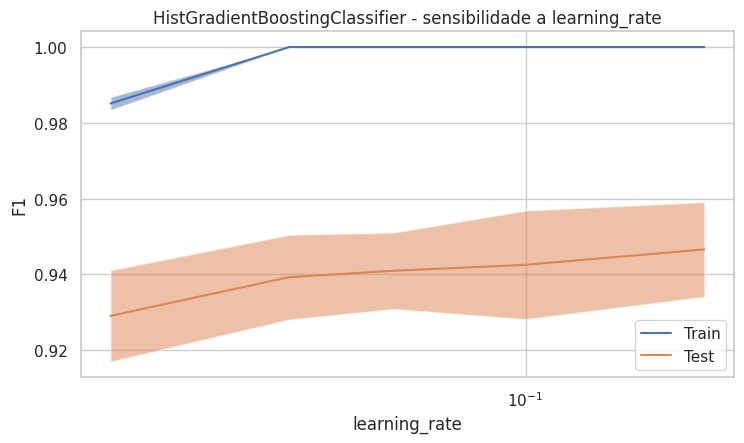

In [101]:
sample_hv_cls_idx = X_train_hv_cls.sample(n=4000, random_state=42).index
X_hv_cls_sample = X_train_hv_cls.loc[sample_hv_cls_idx]
y_hv_cls_sample = y_train_hv_cls.loc[sample_hv_cls_idx]

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ValidationCurveDisplay.from_estimator(
    HistGradientBoostingClassifier(max_leaf_nodes=31, max_iter=220, random_state=42),
    X_hv_cls_sample,
    y_hv_cls_sample,
    param_name='learning_rate',
    param_range=np.array([0.02, 0.04, 0.06, 0.1, 0.2]),
    scoring='f1',
    cv=4,
    ax=ax,
)
ax.set_title('HistGradientBoostingClassifier - sensibilidade a learning_rate')
plt.tight_layout()

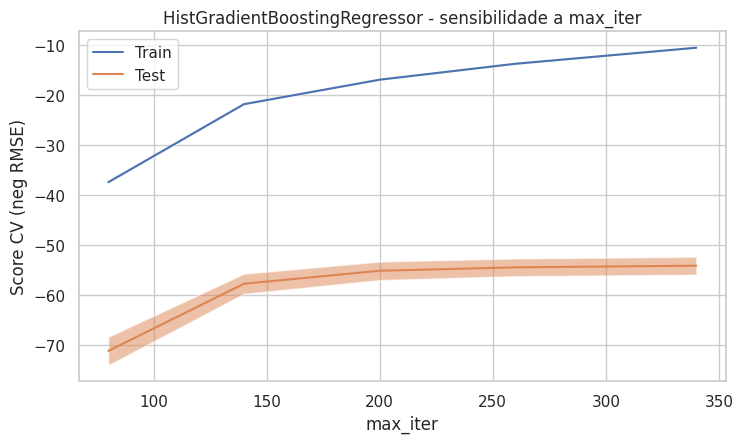

In [102]:
sample_hv_reg_idx = X_train_hv_reg.sample(n=4000, random_state=42).index
X_hv_reg_sample = X_train_hv_reg.loc[sample_hv_reg_idx]
y_hv_reg_sample = y_train_hv_reg.loc[sample_hv_reg_idx]

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ValidationCurveDisplay.from_estimator(
    HistGradientBoostingRegressor(learning_rate=0.06, max_leaf_nodes=31, random_state=42),
    X_hv_reg_sample,
    y_hv_reg_sample,
    param_name='max_iter',
    param_range=np.array([80, 140, 200, 260, 340]),
    scoring='neg_root_mean_squared_error',
    cv=4,
    ax=ax,
)
ax.set_title('HistGradientBoostingRegressor - sensibilidade a max_iter')
ax.set_ylabel('Score CV (neg RMSE)')
plt.tight_layout()

### 7 - Método 4: AdaBoost (Classifier + Regressor)

AdaBoost reforça o peso de exemplos difíceis ao longo das iterações. Funciona muito bem em alguns cenários, mas pode ser sensível a ruído.

In [103]:
ada_cls = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=220,
    learning_rate=0.07,
    random_state=42,
)

ada_cls.fit(X_train_tree_cls, y_train_tree_cls)

ada_cls_table = pd.DataFrame([
    {
        'model': 'DecisionTree_regularizada',
        'f1_test': f1_score(y_test_tree_cls, tree_cls_reg.predict(X_test_tree_cls)),
        'roc_auc_test': roc_auc_score(y_test_tree_cls, tree_cls_reg.predict_proba(X_test_tree_cls)[:, 1]),
    },
    {
        'model': 'RandomForest',
        'f1_test': f1_score(y_test_tree_cls, rf_cls.predict(X_test_tree_cls)),
        'roc_auc_test': roc_auc_score(y_test_tree_cls, rf_cls.predict_proba(X_test_tree_cls)[:, 1]),
    },
    {
        'model': 'HistGBClassifier',
        'f1_test': f1_score(y_test_hv_cls, hgb_cls.predict(X_test_hv_cls)),
        'roc_auc_test': roc_auc_score(y_test_hv_cls, hgb_cls.predict_proba(X_test_hv_cls)[:, 1]),
    },
    {
        'model': 'AdaBoostClassifier',
        'f1_test': f1_score(y_test_tree_cls, ada_cls.predict(X_test_tree_cls)),
        'roc_auc_test': roc_auc_score(y_test_tree_cls, ada_cls.predict_proba(X_test_tree_cls)[:, 1]),
    },
]).sort_values('f1_test', ascending=False).reset_index(drop=True)

ada_cls_table.round(4)

,model,f1_test,roc_auc_test
0,HistGBClassifier,0.9651,0.9886
1,DecisionTree_regularizada,0.9640,0.9817
2,RandomForest,0.9545,0.9886
3,AdaBoostClassifier,0.9292,0.9735


In [104]:
n_estimators_grid = [20, 50, 100, 160, 220, 320]
rows_ada_n = []
for n in n_estimators_grid:
    m = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=n,
        learning_rate=0.07,
        random_state=42,
    )
    m.fit(X_train_tree_cls, y_train_tree_cls)
    pred = m.predict(X_test_tree_cls)
    rows_ada_n.append({'n_estimators': n, 'f1_test': f1_score(y_test_tree_cls, pred)})

ada_n_df = pd.DataFrame(rows_ada_n)

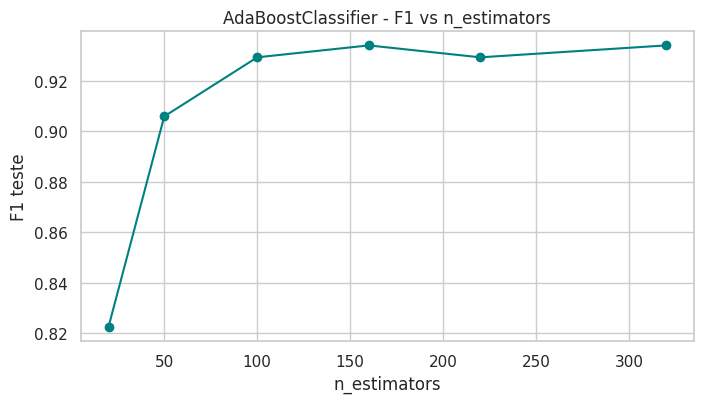

In [105]:
plt.figure(figsize=(7.2, 4.2))
plt.plot(ada_n_df['n_estimators'], ada_n_df['f1_test'], marker='o', color='teal')
plt.title('AdaBoostClassifier - F1 vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('F1 teste')
plt.tight_layout()

In [106]:
lr_grid = [0.01, 0.03, 0.05, 0.08, 0.12, 0.2]
rows_ada_lr = []
for lr in lr_grid:
    m = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=220,
        learning_rate=lr,
        random_state=42,
    )
    m.fit(X_train_tree_cls, y_train_tree_cls)
    pred = m.predict(X_test_tree_cls)
    rows_ada_lr.append({'learning_rate': lr, 'f1_test': f1_score(y_test_tree_cls, pred)})

ada_lr_df = pd.DataFrame(rows_ada_lr)

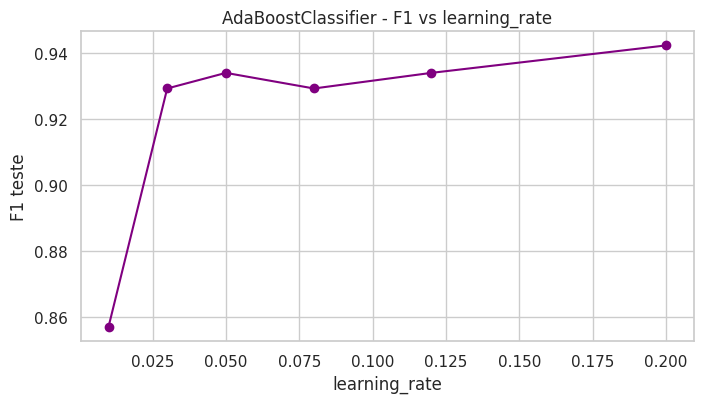

In [107]:
plt.figure(figsize=(7.2, 4.2))
plt.plot(ada_lr_df['learning_rate'], ada_lr_df['f1_test'], marker='o', color='purple')
plt.title('AdaBoostClassifier - F1 vs learning_rate')
plt.xlabel('learning_rate')
plt.ylabel('F1 teste')
plt.tight_layout()

In [108]:
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
    n_estimators=240,
    learning_rate=0.05,
    random_state=42,
)

ada_reg.fit(X_train_fried, y_train_fried)

ada_reg_table = pd.DataFrame([
    {
        'model': 'DecisionTreeRegressor',
        'rmse_test': root_mean_squared_error(y_test_fried, tree_fried.predict(X_test_fried)),
        'r2_test': r2_score(y_test_fried, tree_fried.predict(X_test_fried)),
    },
    {
        'model': 'RandomForestRegressor',
        'rmse_test': root_mean_squared_error(y_test_fried, rf_fried.predict(X_test_fried)),
        'r2_test': r2_score(y_test_fried, rf_fried.predict(X_test_fried)),
    },
    {
        'model': 'HistGBRegressor',
        'rmse_test': root_mean_squared_error(y_test_hv_reg, hgb_reg.predict(X_test_hv_reg)),
        'r2_test': r2_score(y_test_hv_reg, hgb_reg.predict(X_test_hv_reg)),
    },
    {
        'model': 'AdaBoostRegressor',
        'rmse_test': root_mean_squared_error(y_test_fried, ada_reg.predict(X_test_fried)),
        'r2_test': r2_score(y_test_fried, ada_reg.predict(X_test_fried)),
    },
]).sort_values('rmse_test').reset_index(drop=True)

ada_reg_table.round(4)

,model,rmse_test,r2_test
0,RandomForestRegressor,1.7605,0.8768
1,DecisionTreeRegressor,2.4998,0.7517
2,AdaBoostRegressor,2.5711,0.7373
3,HistGBRegressor,33.1360,0.9774


In [109]:
n_estimators_grid_reg = [30, 80, 140, 200, 280, 360]
rows_ada_reg_n = []
for n in n_estimators_grid_reg:
    m = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
        n_estimators=n,
        learning_rate=0.05,
        random_state=42,
    )
    m.fit(X_train_fried, y_train_fried)
    pred = m.predict(X_test_fried)
    rows_ada_reg_n.append({'n_estimators': n, 'rmse_test': root_mean_squared_error(y_test_fried, pred)})

ada_reg_n_df = pd.DataFrame(rows_ada_reg_n)

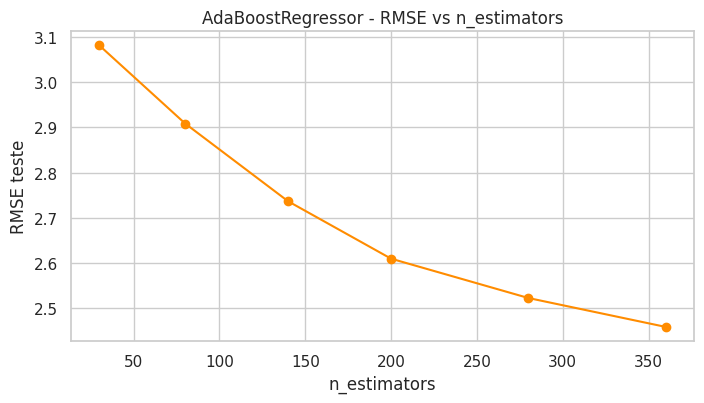

In [110]:
plt.figure(figsize=(7.2, 4.2))
plt.plot(ada_reg_n_df['n_estimators'], ada_reg_n_df['rmse_test'], marker='o', color='darkorange')
plt.title('AdaBoostRegressor - RMSE vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('RMSE teste')
plt.tight_layout()

In [111]:
lr_grid_reg = [0.01, 0.03, 0.05, 0.08, 0.12, 0.2]
rows_ada_reg_lr = []
for lr in lr_grid_reg:
    m = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
        n_estimators=240,
        learning_rate=lr,
        random_state=42,
    )
    m.fit(X_train_fried, y_train_fried)
    pred = m.predict(X_test_fried)
    rows_ada_reg_lr.append({'learning_rate': lr, 'rmse_test': root_mean_squared_error(y_test_fried, pred)})

ada_reg_lr_df = pd.DataFrame(rows_ada_reg_lr)

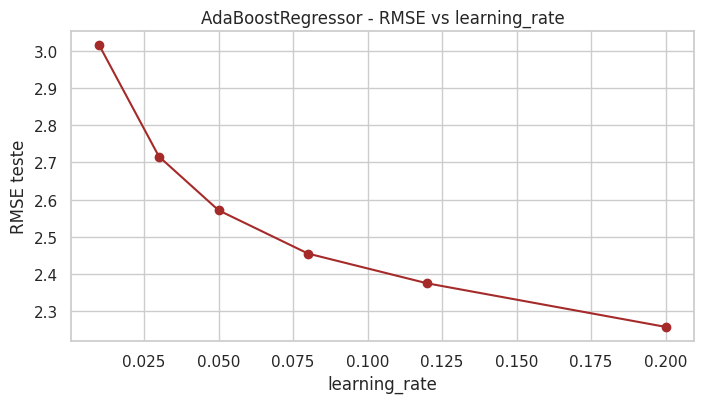

In [112]:
plt.figure(figsize=(7.2, 4.2))
plt.plot(ada_reg_lr_df['learning_rate'], ada_reg_lr_df['rmse_test'], marker='o', color='brown')
plt.title('AdaBoostRegressor - RMSE vs learning_rate')
plt.xlabel('learning_rate')
plt.ylabel('RMSE teste')
plt.tight_layout()

### 8 - Comparativo final por tarefa com **cross_validate**

Agora consolidamos os modelos em validação cruzada para reduzir dependência de um único split holdout.

In [113]:
X_cv_clf = X_class_imbalanced.copy()
y_cv_clf = y_class_imbalanced.copy()

cv_clf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

clf_models_cv = {
    'DummyClassifier': DummyClassifier(strategy='most_frequent'),
    'DecisionTreeClassifier': DecisionTreeClassifier(max_depth=6, min_samples_leaf=8, random_state=42),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=160, max_depth=10, min_samples_leaf=4, random_state=42, n_jobs=-1),
    'AdaBoostClassifier': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=220, learning_rate=0.07, random_state=42),
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier(learning_rate=0.06, max_leaf_nodes=31, max_iter=240, random_state=42),
    'XGBClassifier': XGBClassifier(objective='binary:logistic', eval_metric='logloss', tree_method='hist', learning_rate=0.06, max_depth=6, n_estimators=220, subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1),
}

In [114]:
rows_cv_clf = []
for name, model in clf_models_cv.items():
    cv_out = cross_validate(
        model,
        X_cv_clf,
        y_cv_clf,
        cv=cv_clf,
        scoring={
            'accuracy': 'accuracy',
            'balanced_accuracy': 'balanced_accuracy',
            'precision': make_scorer(precision_score, zero_division=0),
            'recall': make_scorer(recall_score, zero_division=0),
            'f1': make_scorer(f1_score, zero_division=0),
            'roc_auc': 'roc_auc',
        },
        return_train_score=False,
        error_score=np.nan,
    )

    rows_cv_clf.append({
        'model': name,
        'accuracy_cv_mean': cv_out['test_accuracy'].mean(),
        'balanced_accuracy_cv_mean': cv_out['test_balanced_accuracy'].mean(),
        'precision_cv_mean': cv_out['test_precision'].mean(),
        'recall_cv_mean': cv_out['test_recall'].mean(),
        'f1_cv_mean': cv_out['test_f1'].mean(),
        'roc_auc_cv_mean': cv_out['test_roc_auc'].mean(),
        'fit_time_cv_mean': cv_out['fit_time'].mean(),
    })

cv_clf_table = pd.DataFrame(rows_cv_clf).sort_values('f1_cv_mean', ascending=False).reset_index(drop=True)
cv_clf_table.round(4)

,model,accuracy_cv_mean,balanced_accuracy_cv_mean,precision_cv_mean,recall_cv_mean,f1_cv_mean,roc_auc_cv_mean,fit_time_cv_mean
0,HistGradientBoostingClassifier,0.9673,0.8654,0.9703,0.7339,0.8339,0.9289,0.3128
1,XGBClassifier,0.9669,0.8630,0.9718,0.7288,0.8316,0.9303,0.2158
2,RandomForestClassifier,0.9456,0.7652,0.9729,0.5324,0.6871,0.9307,0.1395
3,DecisionTreeClassifier,0.9308,0.7621,0.7747,0.5443,0.6389,0.8385,0.0299
4,AdaBoostClassifier,0.9063,0.5904,0.9329,0.1826,0.3048,0.8788,1.3714
5,DummyClassifier,0.8873,0.5000,0.0000,0.0000,0.0000,0.5000,0.0007


In [115]:
X_cv_reg = X_reg_friedman.copy()
y_cv_reg = y_reg_friedman.copy()

cv_reg = KFold(n_splits=4, shuffle=True, random_state=42)

reg_models_cv = {
    'DummyRegressor': DummyRegressor(strategy='mean'),
    'DecisionTreeRegressor': DecisionTreeRegressor(max_depth=7, min_samples_leaf=8, random_state=42),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=180, max_depth=12, min_samples_leaf=4, random_state=42, n_jobs=-1),
    'AdaBoostRegressor': AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3, random_state=42), n_estimators=240, learning_rate=0.05, random_state=42),
    'HistGradientBoostingRegressor': HistGradientBoostingRegressor(learning_rate=0.06, max_leaf_nodes=31, max_iter=240, random_state=42),
    'XGBRegressor': XGBRegressor(objective='reg:squarederror', eval_metric='rmse', tree_method='hist', learning_rate=0.06, max_depth=6, n_estimators=220, subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1),
}

In [116]:
rows_cv_reg = []
for name, model in reg_models_cv.items():
    cv_out = cross_validate(
        model,
        X_cv_reg,
        y_cv_reg,
        cv=cv_reg,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2',
        },
        return_train_score=False,
        error_score=np.nan,
    )

    rows_cv_reg.append({
        'model': name,
        'rmse_cv_mean': -cv_out['test_rmse'].mean(),
        'mae_cv_mean': -cv_out['test_mae'].mean(),
        'r2_cv_mean': cv_out['test_r2'].mean(),
        'fit_time_cv_mean': cv_out['fit_time'].mean(),
    })

cv_reg_table = pd.DataFrame(rows_cv_reg).sort_values('rmse_cv_mean').reset_index(drop=True)
cv_reg_table.round(4)

,model,rmse_cv_mean,mae_cv_mean,r2_cv_mean,fit_time_cv_mean
0,HistGradientBoostingRegressor,1.4319,1.1448,0.9192,0.2698
1,XGBRegressor,1.4397,1.1499,0.9183,0.2074
2,RandomForestRegressor,1.8279,1.4463,0.8683,0.1247
3,DecisionTreeRegressor,2.5290,2.0180,0.7478,0.0104
4,AdaBoostRegressor,2.5968,2.0778,0.7343,1.1702
5,DummyRegressor,5.0397,4.0948,-0.0004,0.0003


**Quando usar / quando evitar (resumo por família)**

| Família | Quando usar | Evitar quando |
|---|---|---|
| Decision Tree | baseline interpretável, regras rápidas | alta variância sem regularização |
| Random Forest | robustez e bom desempenho tabular geral | quando latência/memória são muito restritas |
| HistGradientBoosting | tabular com não linearidade e bom custo-benefício | quando tuning é mínimo e dataset é muito pequeno |
| AdaBoost | melhora incremental com modelos fracos simples | presença forte de ruído/outliers |
| XGBoost | alta performance tabular com controle fino | custo de tuning e tempo de experimento muito restritos |